In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn joblib

Note: you may need to restart the kernel to use updated packages.


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    mean_squared_error, mean_absolute_error, accuracy_score
)
import joblib

sns.set(style="whitegrid")

In [17]:
df = pd.read_csv("C:\\Users\\valle\\Downloads\\framingham.csv")

print(df.shape)
print(df.dtypes)
print(df.head())
print(df.describe())

(4238, 16)
male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object
   male  age  education  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0     1   39        4.0              0         0.0     0.0                0   
1     0   46        2.0              0         0.0     0.0                0   
2     1   48        1.0              1        20.0     0.0                0   
3     0   61        3.0              1        30.0     0.0                0   
4     0   46        3.0              1        23.0     0.0                0   

   prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  

In [18]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
print(pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}))

                 Missing Count  Missing %
male                         0   0.000000
age                          0   0.000000
education                  105   2.477584
currentSmoker                0   0.000000
cigsPerDay                  29   0.684285
BPMeds                      53   1.250590
prevalentStroke              0   0.000000
prevalentHyp                 0   0.000000
diabetes                     0   0.000000
totChol                     50   1.179802
sysBP                        0   0.000000
diaBP                        0   0.000000
BMI                         19   0.448325
heartRate                    1   0.023596
glucose                    388   9.155262
TenYearCHD                   0   0.000000


In [19]:
num_cols = ['education', 'cigsPerDay', 'BPMeds', 'totChol', 'BMI', 'heartRate', 'glucose']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum().sum())

0


TenYearCHD
0    3594
1     644
Name: count, dtype: int64
TenYearCHD
0    84.804153
1    15.195847
Name: proportion, dtype: float64


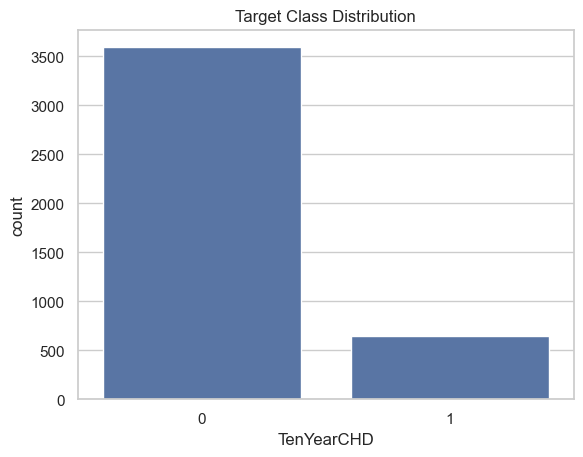

In [20]:
print(df['TenYearCHD'].value_counts())
print(df['TenYearCHD'].value_counts(normalize=True) * 100)

sns.countplot(x='TenYearCHD', data=df)
plt.title("Target Class Distribution")
plt.show()

TenYearCHD         1.000000
age                0.225256
sysBP              0.216429
prevalentHyp       0.177603
diaBP              0.145299
glucose            0.121277
diabetes           0.097317
male               0.088428
BPMeds             0.086417
totChol            0.081566
BMI                0.074217
prevalentStroke    0.061810
cigsPerDay         0.058859
heartRate          0.022857
currentSmoker      0.019456
education         -0.053383
Name: TenYearCHD, dtype: float64


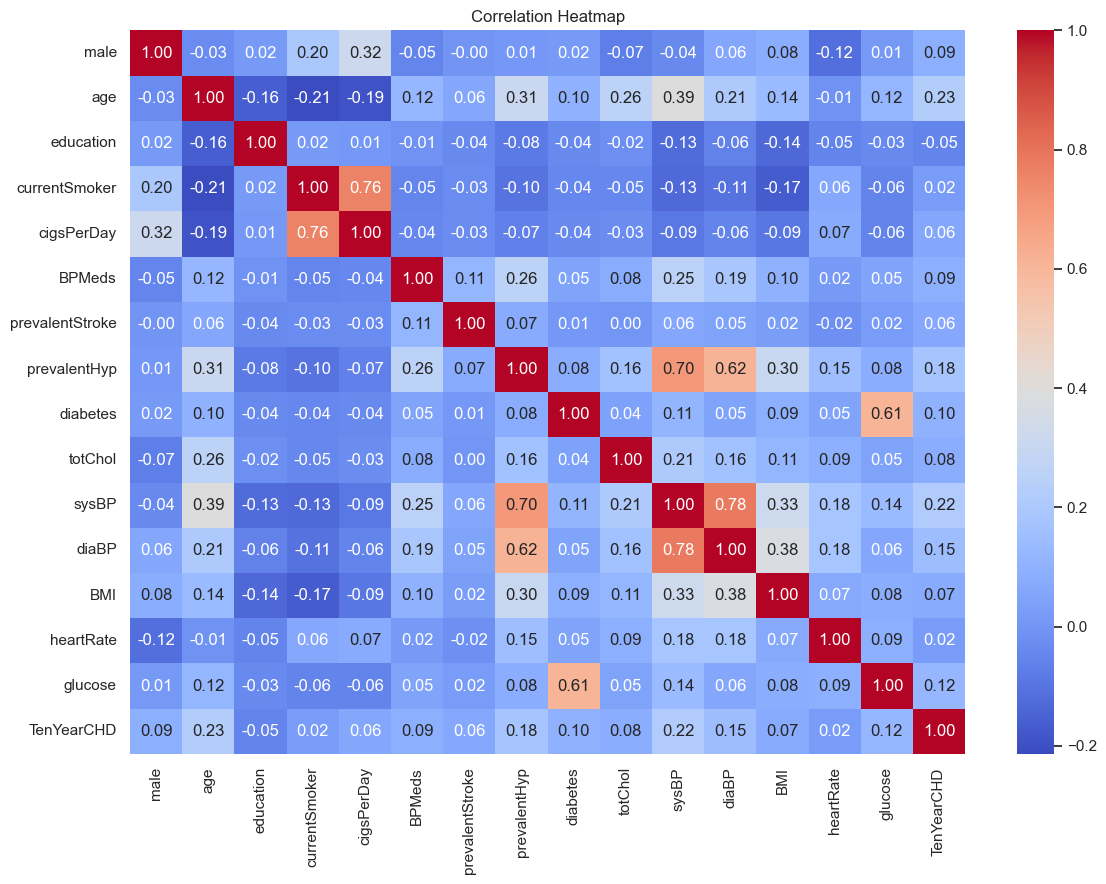

In [30]:
corr = df.corr()
print(corr['TenYearCHD'].sort_values(ascending=False))

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

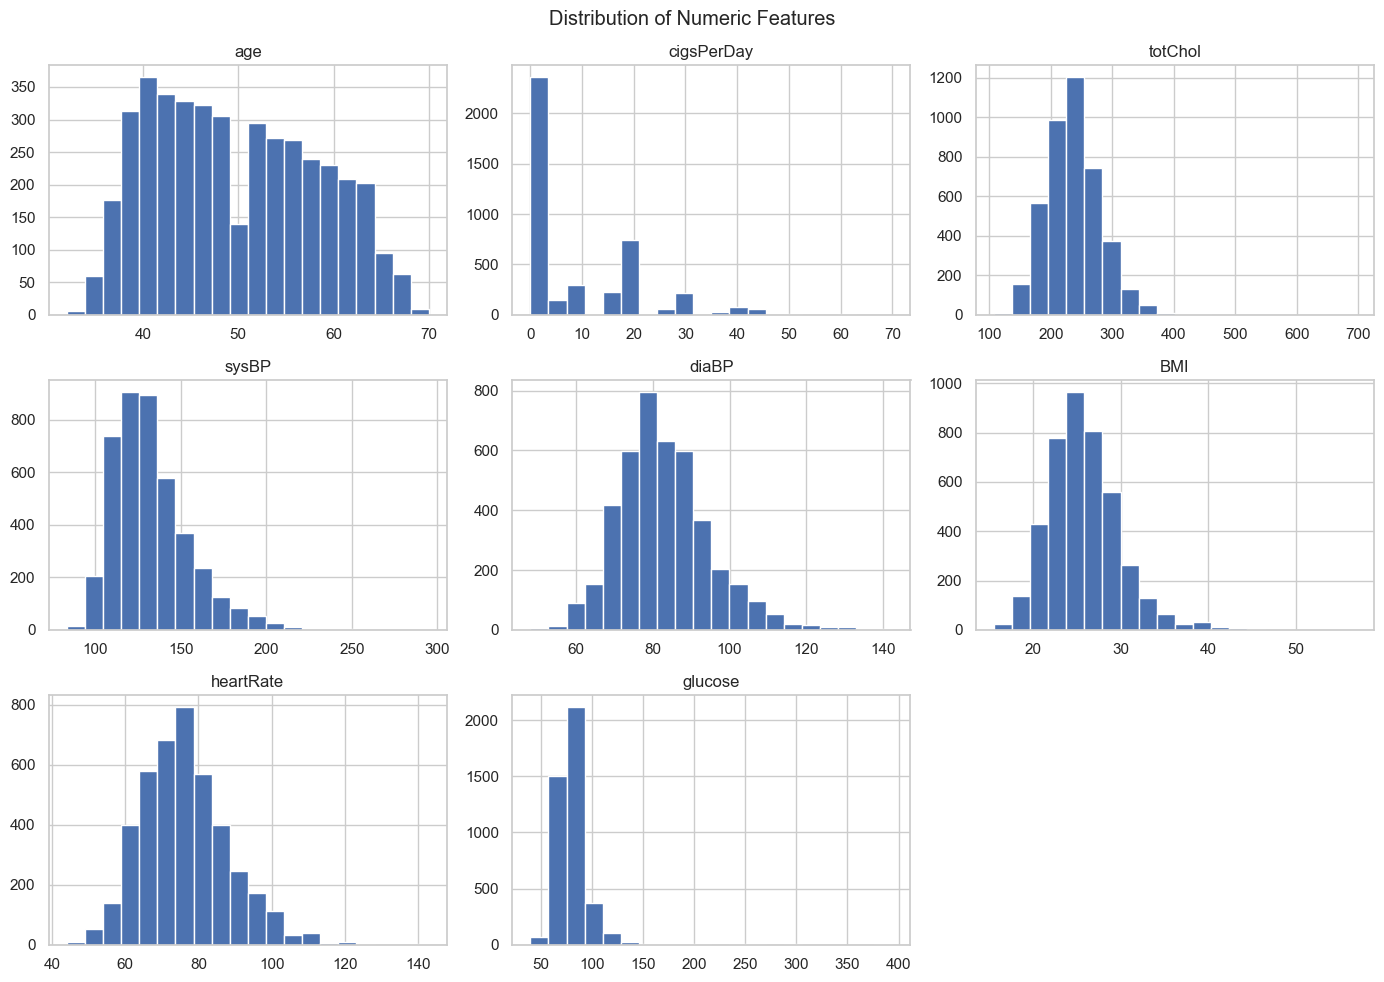

In [21]:
num_features = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

df[num_features].hist(bins=20, figsize=(14, 10))
plt.suptitle("Distribution of Numeric Features")
plt.tight_layout()
plt.show()

In [22]:
X = df.drop('TenYearCHD', axis=1)
y = df['TenYearCHD']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(3390, 15) (848, 15)


In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
log_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_proba_log = log_model.predict_proba(X_test_scaled)[:, 1]

In [25]:
rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=8, class_weight='balanced', random_state=42
)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
y_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

In [26]:
print("Logistic Regression")
print(classification_report(y_test, y_pred_log))
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_log))

print("\nRandom Forest")
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

Logistic Regression
              precision    recall  f1-score   support

           0       0.90      0.69      0.78       719
           1       0.25      0.58      0.35       129

    accuracy                           0.67       848
   macro avg       0.58      0.63      0.56       848
weighted avg       0.80      0.67      0.71       848

Accuracy: 0.6709905660377359
ROC-AUC: 0.698472253668424

Random Forest
              precision    recall  f1-score   support

           0       0.88      0.85      0.86       719
           1       0.28      0.33      0.30       129

    accuracy                           0.77       848
   macro avg       0.58      0.59      0.58       848
weighted avg       0.79      0.77      0.78       848

Accuracy: 0.7676886792452831
ROC-AUC: 0.6744509493159103


In [27]:
print("Logistic Regression -> MSE:", mean_squared_error(y_test, y_pred_log),
      "MAE:", mean_absolute_error(y_test, y_pred_log))
print("Random Forest -> MSE:", mean_squared_error(y_test, y_pred_rf),
      "MAE:", mean_absolute_error(y_test, y_pred_rf))

Logistic Regression -> MSE: 0.3290094339622642 MAE: 0.3290094339622642
Random Forest -> MSE: 0.23231132075471697 MAE: 0.23231132075471697


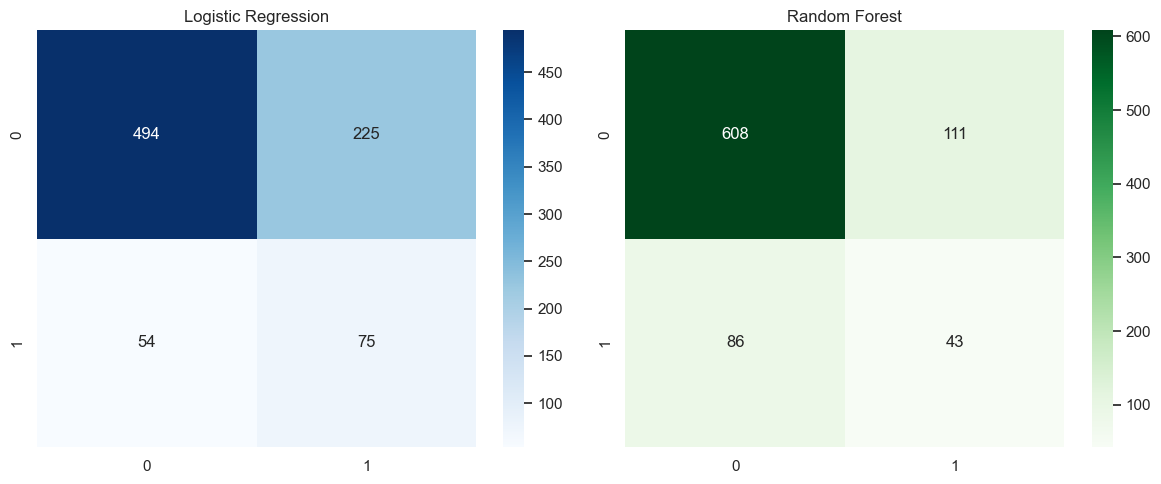

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title("Logistic Regression")

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', ax=axes[1], cmap='Greens')
axes[1].set_title("Random Forest")
plt.tight_layout()
plt.show()

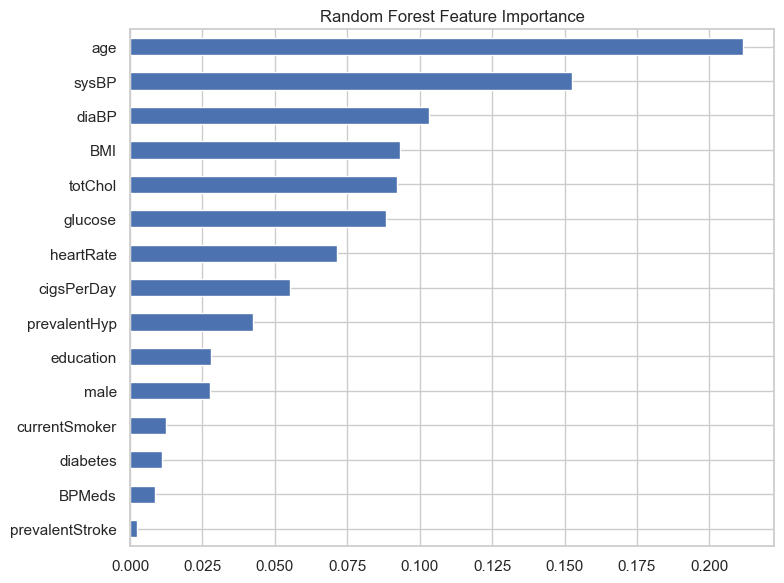

age                0.211718
sysBP              0.152414
diaBP              0.103223
BMI                0.093113
totChol            0.092076
glucose            0.088433
heartRate          0.071360
cigsPerDay         0.055316
prevalentHyp       0.042381
education          0.028017
male               0.027727
currentSmoker      0.012316
diabetes           0.010880
BPMeds             0.008569
prevalentStroke    0.002456
dtype: float64


In [28]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh')
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importances)

In [29]:
joblib.dump(rf_model, "framingham_rf_model.pkl")
joblib.dump(scaler, "framingham_scaler.pkl")
print("Saved successfully.")

Saved successfully.
